Name :- Akshit Negi

CU24250214

BTech CSE 3rd Year SECTION - "B"

Roll No. :- 4

Experiment No. 2

Experiment Name :

Contrast Enhancement and Histogram-Based Image Processing using Python and OpenCV

Aim:

To analyze and implement contrast enhancement techniques using histogram analysis and histogram equalization in Python and OpenCV for improving image quality and enhancing visual information in low-contrast images.

**Step 1-> Import the required libraries, including OpenCV, NumPy, and Matplotlib.**

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

**Step 2->Load a low-contrast grayscale image or convert a color image into grayscale for processing.**

In [ ]:
print("Please upload an image file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img_color = cv2.imread(file_name)
if img_color is None:
    raise FileNotFoundError("Image file could not be loaded.")

gray_img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

Please upload an image file:


Saving jpeg(1) to jpeg(1)


**Step 3-> Display the original image and generate its histogram to analyze the distribution of pixel intensity values.**

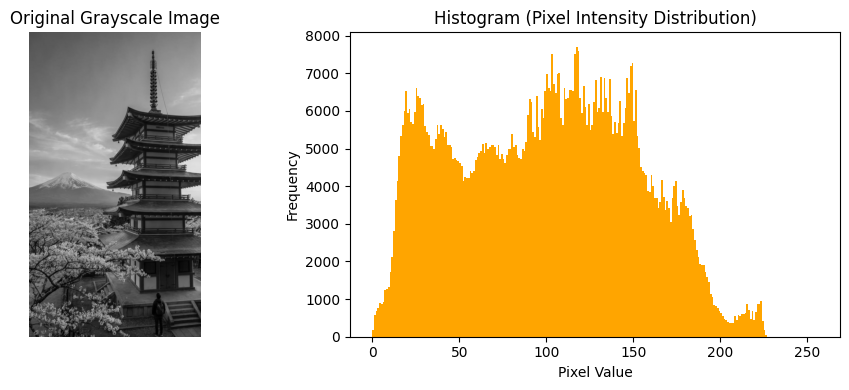

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color="orange")
plt.title("Histogram (Pixel Intensity Distribution)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 4-> Perform contrast stretching to improve the dynamic range of pixel intensities.**

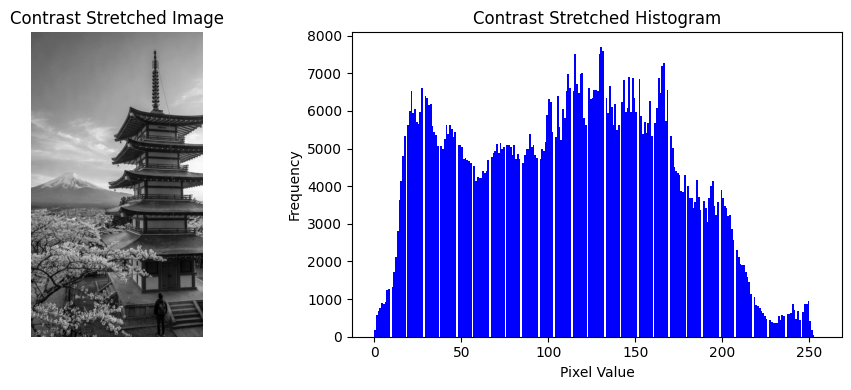

In [ ]:
r_min, r_max = np.min(gray_img), np.max(gray_img)


contrast_stretched = (
    (gray_img - r_min) / (r_max - r_min) * 255.0
).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(contrast_stretched, cmap="gray", vmin=0, vmax=255)
plt.title("Contrast Stretched Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(contrast_stretched.ravel(), bins=256, range=[0, 256], color="blue")
plt.title("Contrast Stretched Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 5->Apply Histogram Equalization using OpenCV and compare the enhanced image with the original image.**

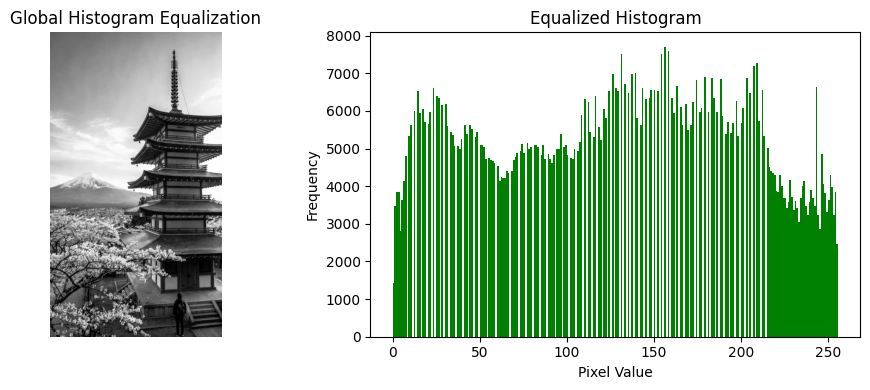

In [ ]:
hist_eq = cv2.equalizeHist(gray_img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(hist_eq, cmap="gray", vmin=0, vmax=255)
plt.title("Global Histogram Equalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(hist_eq.ravel(), bins=256, range=[0, 256], color="green")
plt.title("Equalized Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 6->Implement Contrast Limited Adaptive Histogram Equalization (CLAHE) and observe its performance on images with varying illumination.**

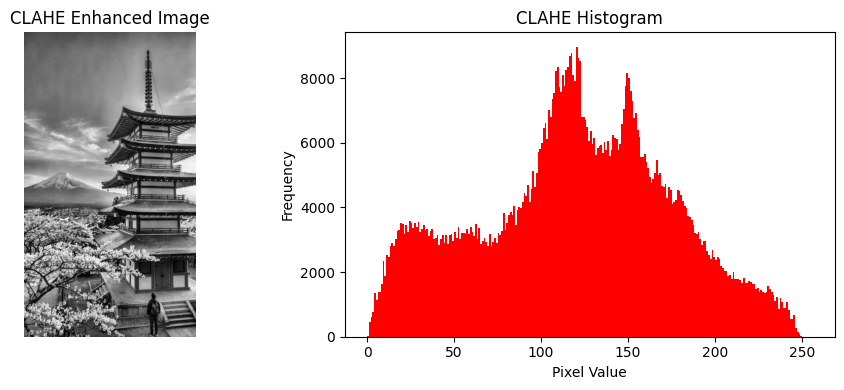

In [ ]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray_img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)
plt.title("CLAHE Enhanced Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(clahe_img.ravel(), bins=256, range=[0, 256], color="red")
plt.title("CLAHE Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 7->Plot and compare the histograms of the original, histogram-equalized, and CLAHE enhanced images.**

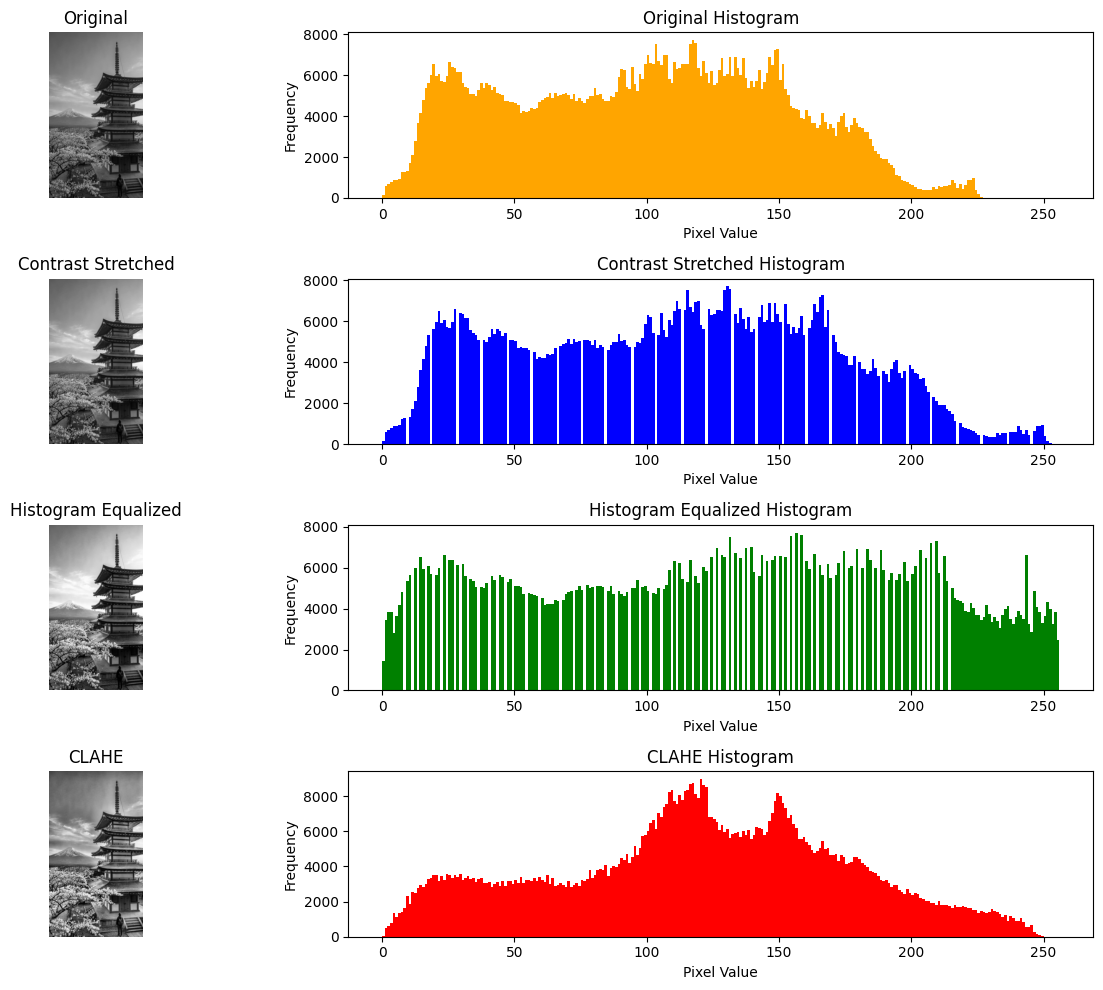

In [ ]:
titles = [
    "Original",
    "Contrast Stretched",
    "Histogram Equalized",
    "CLAHE",
]
processed_images = [gray_img, contrast_stretched, hist_eq, clahe_img]
colors = ["orange", "blue", "green", "red"]

plt.figure(figsize=(14, 10))
for i in range(4):

    plt.subplot(4, 2, 2 * i + 1)
    plt.imshow(processed_images[i], cmap="gray", vmin=0, vmax=255)
    plt.title(titles[i])
    plt.axis("off")

    plt.subplot(4, 2, 2 * i + 2)
    plt.hist(
        processed_images[i].ravel(),
        bins=256,
        range=[0, 256],
        color=colors[i],
    )
    plt.title(f"{titles[i]} Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#Question / Answer

### 1. What is image contrast, and why is it important in image processing?

Image contrast is the difference in visual intensity or color between dark and light regions within an image. High contrast provides a wide dynamic range with distinct darks and lights, while low contrast produces a flat, washed-out appearance with a narrow range of intensities. Contrast is critical because it highlights edges, textures, and structural boundaries, making key features easier to detect for both human observers and automated computer vision algorithms.

### 2. Explain the concept of an image histogram. What information does it provide?

An image histogram is a graphical representation of the pixel intensity distribution. The horizontal axis represents the available intensity values (e.g., 0 to 255 for an 8-bit image), while the vertical axis shows the total count of pixels at each intensity level. It provides critical spatial insights into overall image brightness, contrast levels, dynamic range usage, and whether an image is underexposed (skewed left) or overexposed (skewed right).

### 3. Differentiate between Histogram Stretching and Histogram Equalization.

**Histogram Stretching (Contrast Stretching):** A linear transformation that stretches a narrow range of input intensity values across the entire available dynamic range (e.g., 0 to 255) without changing the shape or relative peak proportions of the histogram.

**Histogram Equalization:** A non-linear transformation based on the Cumulative Distribution Function (CDF) that flattens and re-distributes pixel intensities uniformly to produce a flat histogram, maximizing global contrast.

### 4. What is Contrast Limited Adaptive Histogram Equalization (CLAHE)? How does it differ from standard Histogram Equalization?

CLAHE is an advanced variant of Adaptive Histogram Equalization (AHE) that operates on small local regions (tiles) of an image rather than the entire frame. Unlike standard Histogram Equalization—which calculates a single global transformation and often amplifies unwanted background noise—CLAHE clips local histograms at a predefined threshold to prevent over-amplification of noise, blending neighboring tiles using bilinear interpolation for smooth visual transitions.

### 5. Why is histogram equalization commonly applied before feature extraction and image segmentation?

Histogram equalization spreads pixel intensities evenly, sharpening low-contrast edges and accentuating subtle surface textures. In feature extraction, it makes key descriptors (such as SIFT or Harris corners) more distinct and invariant to poor lighting. In segmentation, it creates sharp intensity boundaries between objects and the background, simplifying thresholding and contour detection.

### 6. Mention three real-world applications where histogram equalization is widely used.

**Medical Diagnostic Imaging:** Sharpening subtle tissue details, bone fractures, and tumors in low-contrast X-rays, CT scans, and MRIs.

**Satellite and Aerial Remote Sensing:** Revealing terrain features, vegetation, and water bodies in satellite imagery shadowed by cloud cover or sunlight angles.

**Underwater and Night Vision Systems:** Enhancing clarity and visibility in murky water or low-light security camera footage.

### 7. What are the limitations of global histogram equalization?

**Noise Over-Amplification:** It amplifies background sensor noise in near-constant or flat intensity regions.

**Loss of Local Detail:** Global equalization adjusts the entire image uniformly, which can wash out details in regions that are already well-exposed.

**Unnatural Visual Artifacts:** It often shifts average brightness dramatically, causing unnaturally stark contrast or halo effects.

### 8. How does contrast enhancement improve the performance of object detection and recognition systems?

Contrast enhancement sharpens blurry object boundaries and normalizes lighting variations across different input images. By making feature gradients more prominent, it helps deep learning models and traditional classifiers reliably detect object outlines, facial features, or keypoints under adverse, non-uniform, or low-light environmental conditions.

### 9. Compare histogram-based enhancement techniques with brightness adjustment methods.

**Brightness Adjustment:** A simple linear addition or subtraction operation ($I_{out} = I_{in} + c$) that shifts the entire histogram left or right, changing overall lightness without expanding the range or improving contrast between adjacent pixels.

**Histogram-Based Enhancement:** A dynamic or non-linear transformation that stretches or reorganizes pixel intensity distributions based on image statistical properties, directly expanding dynamic range and boosting feature contrast.

### 10. Why is CLAHE preferred for medical imaging and low-light image enhancement?

Medical scans and low-light scenes contain delicate, localized variations in tone that global methods flatten or oversaturate. CLAHE works on local neighborhoods, boosting contrast in dark or faint regions while applying a contrast clip limit to prevent noise over-amplification—preserving soft tissue details and fine structural features without introducing visual artifacts.